Showing: 000001.npy (72, 304)


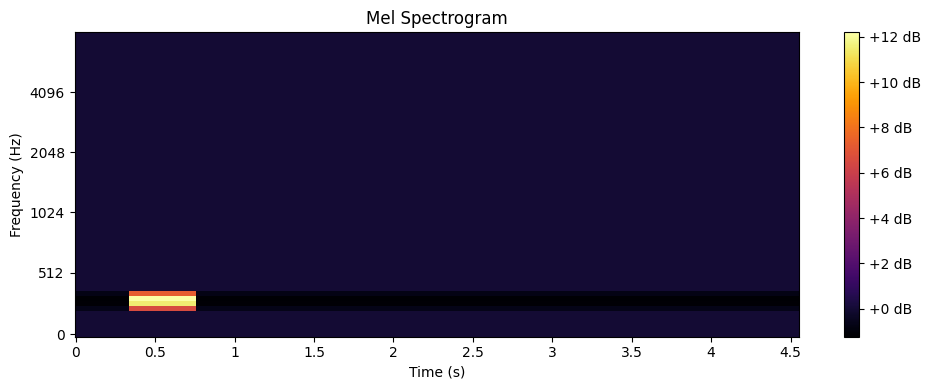

Showing: 000002.npy (72, 304)


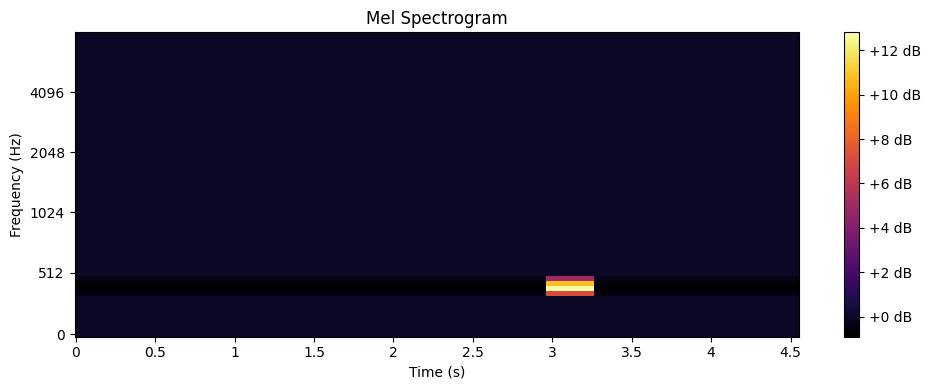

Showing: 000003.npy (72, 304)


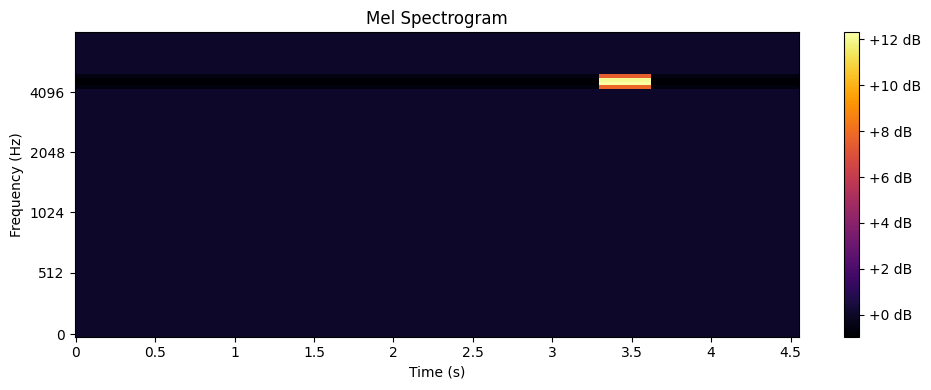

Showing: 000004.npy (72, 304)


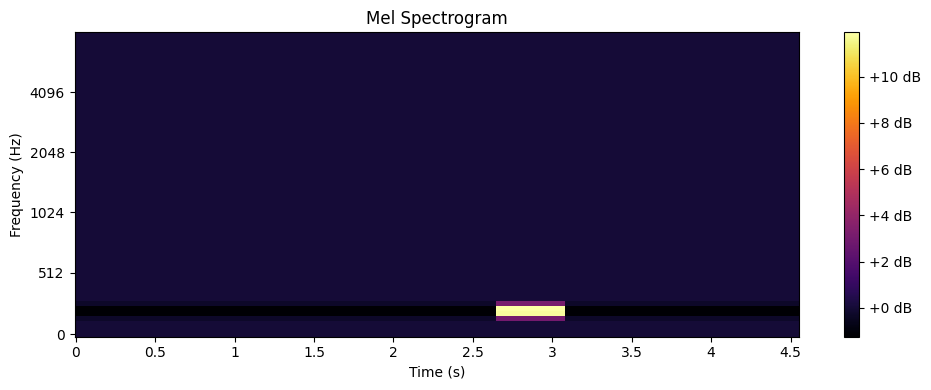

Showing: 000005.npy (72, 304)


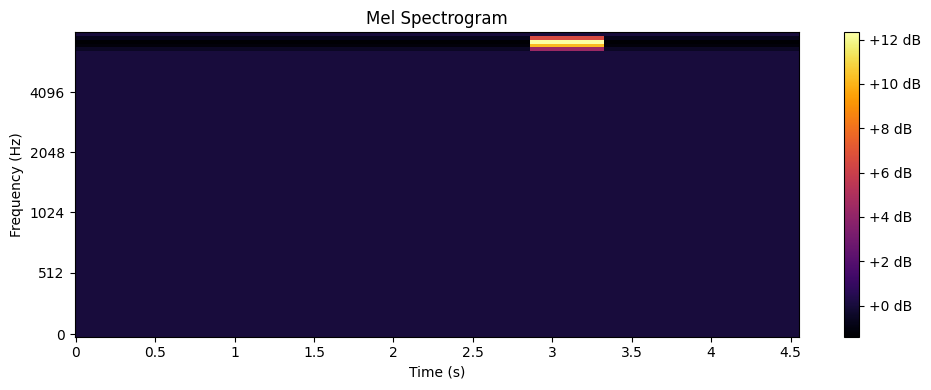

Showing: 000006.npy (72, 304)


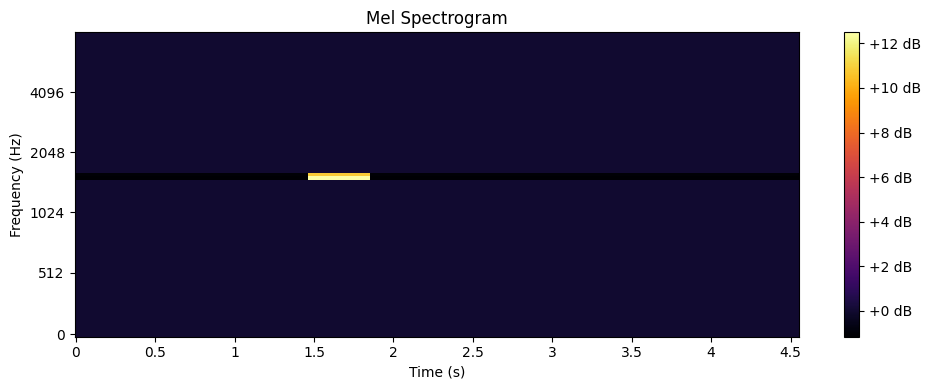

Showing: 000007.npy (72, 304)


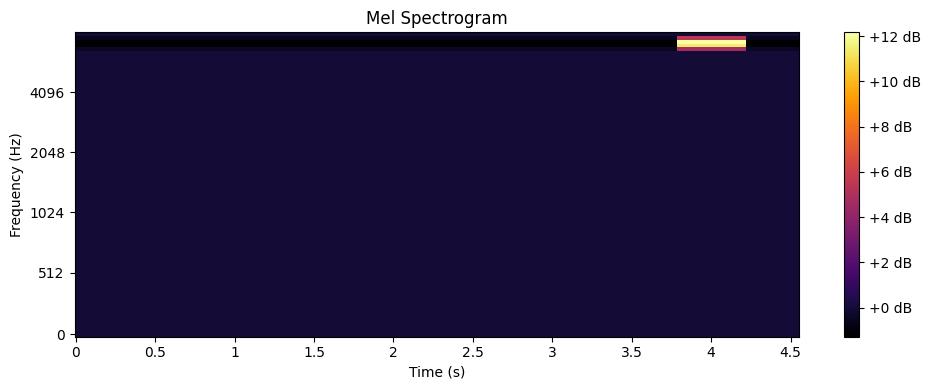

Showing: 000008.npy (72, 304)


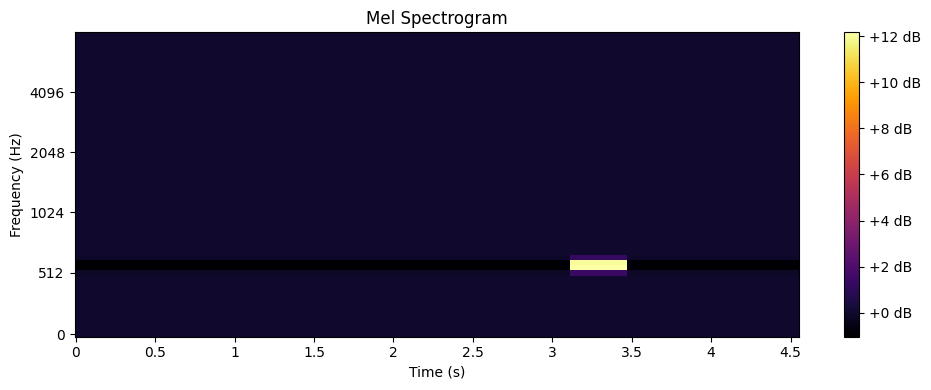

Showing: 000009.npy (72, 304)


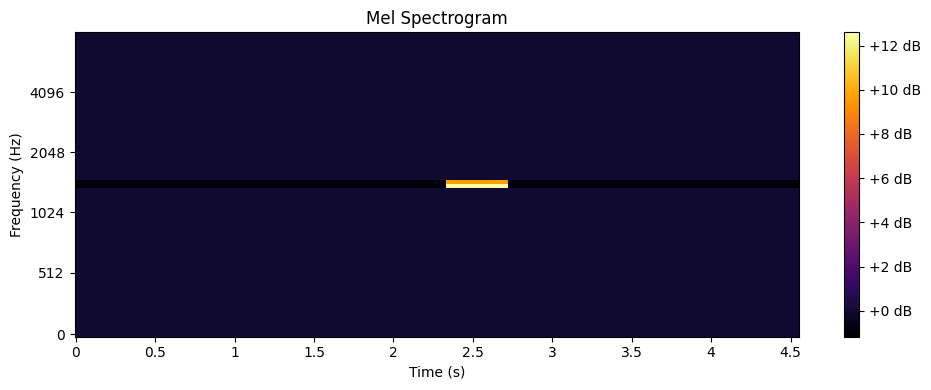

Showing: 000010.npy (72, 304)


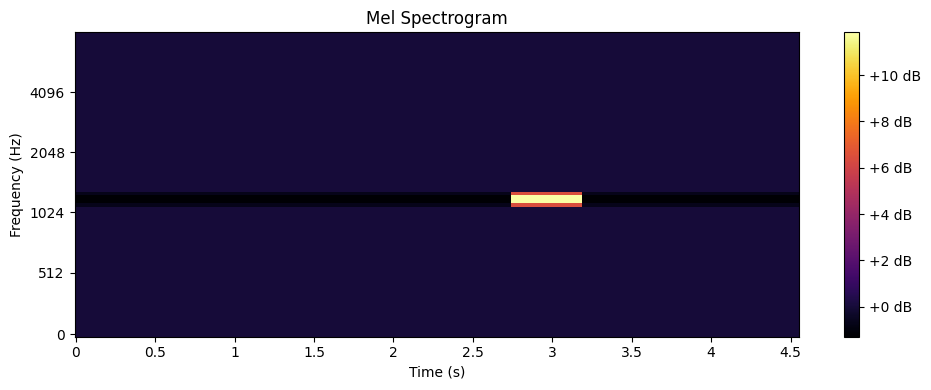

Showing: 000011.npy (72, 304)


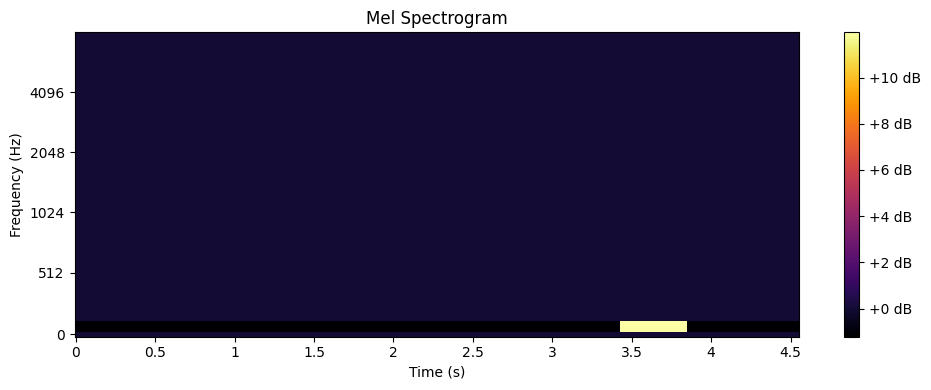

Showing: 000012.npy (72, 304)


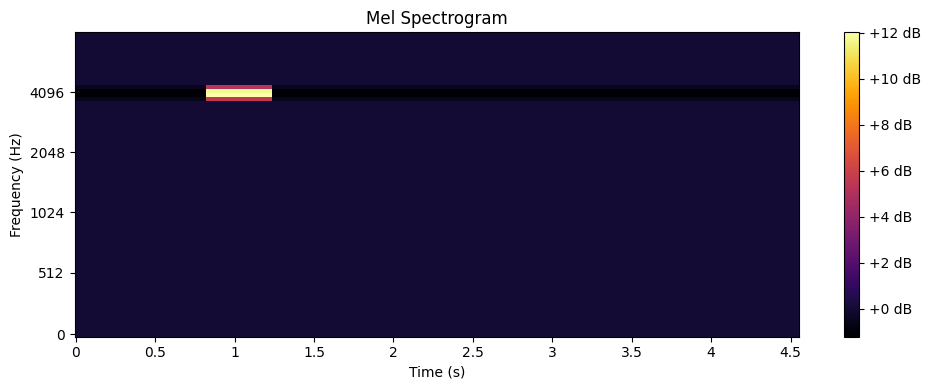

Showing: 000013.npy (72, 304)


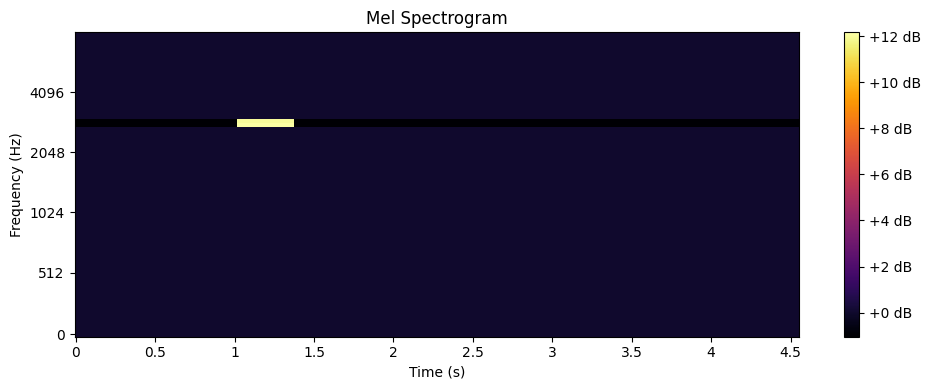

Showing: 000014.npy (72, 304)


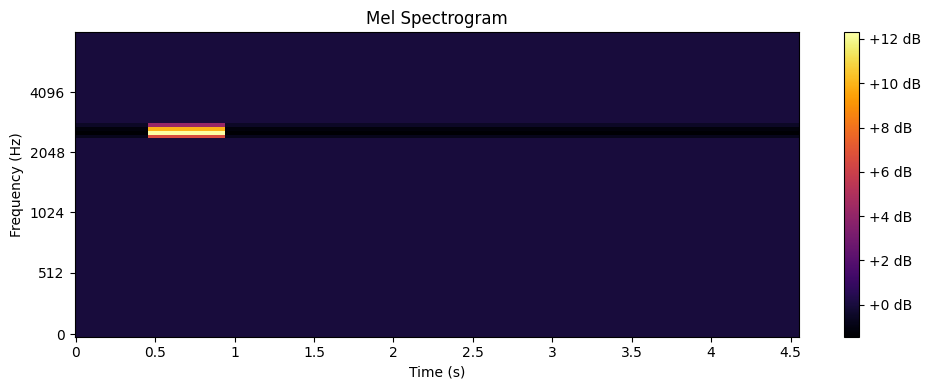

Showing: 000015.npy (72, 304)


KeyboardInterrupt: 

In [ ]:
from pathlib import Path
import numpy as np
from Visualizations import plot_mel_spectrogram
from matplotlib import pyplot as plt
# concepts_root = Path("temp_concepts") # for redimnet
concepts_root = Path("temp_concepts")  # for resnet_293
concept_dirs = sorted([d for d in concepts_root.iterdir() if d.is_dir()])

def pick_sample_npy(concept_dir: Path) -> Path | None:
    npy_files = sorted(concept_dir.glob("*.npy"))
    if not npy_files:
        return None
    # Prefer numbered samples (e.g., 000001.npy). Skip raw_energy.npy.
    numbered = [p for p in npy_files if p.stem.isdigit()]
    if numbered:
        return numbered[0]
    
    for p in npy_files:
        if p.name != "raw_energy.npy":
            return p
    return npy_files[0]

for concept_dir in concept_dirs:
    npy_files = sorted(concept_dir.glob("*.npy"))
    # for p in npy_files:
    #     arr = np.load(p)
    #     print("Showing:", p.name, arr.shape)
    #     plot_mel_spectrogram(arr, block=False)
        # plt.show()
    sample_path = pick_sample_npy(concept_dir)
    if sample_path is None:
        print(f"Folder {concept_dir.name} has no files — skipping")
        continue

    sample = np.load(sample_path)
    print("\n=== Showing concept:", concept_dir.name, "===", sample.shape, "file=", sample_path.name)
    plot_mel_spectrogram(sample)
